In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
from metrics.graph import compare_dags
from utils.results import *


In [2]:

import pickle
subset='jpmf_grid'

def load_results(subset):
    global results_by_label

    with open(f'results/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    with open(f'results/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    with open(f'results/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)


    # with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
    #     results_ea_ues = pickle.load(f)
    # with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
    #     results_ea_ies = pickle.load(f)
    # with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
    #     results_ea_fes = pickle.load(f)

    # with open(f'results/ea_upu/{subset}.pkl', 'rb') as f:
    #     results_ea_upu = pickle.load(f)
    # with open(f'results/ea_ipu/{subset}.pkl', 'rb') as f:
    #     results_ea_ipu = pickle.load(f)
    
    with open(f'results/ea_final_greedy/{subset}.pkl', 'rb') as f:
        results_ea_final_greedy = pickle.load(f)

    results_by_label = {
        # "PC": results_pc,
        "GES": results_ges,
        "HC": results_hc,
        "EA Final Greedy": results_ea_final_greedy,
        # "EA Uninformed": results_ea_ues,
        # "EA Informed": results_ea_ies,
        # "EA Fully Informed": results_ea_fes,
        # "EA Uninformed (PU)": results_ea_upu,
        # "EA Informed (PU)": results_ea_ipu,
    }
    
load_results(subset)
mapping=f"experiments/RQ1/{subset}/grid_mapping.csv"

FileNotFoundError: [Errno 2] No such file or directory: 'results/pc/jpmf_grid.pkl'

In [ ]:
ea = results_by_label["EA Final Greedy"]
hc = results_by_label["HC"]
ges = results_by_label["GES"]

                 mean      median           min          max
delta_ea   421.796785  362.890277  0.000000e+00  1231.952490
delta_hc   410.749399  221.079242 -2.535232e+01  1409.299811
delta_ges  472.803407  313.564076 -2.910383e-11  1927.049706
best_alg
delta_ea     17
delta_hc     11
delta_ges     8
Name: count, dtype: int64

Within Δ <= 2:
  ea: 5.56%
  hc: 2.78%
  ges: 2.78%

Within Δ <= 6:
  ea: 5.56%
  hc: 2.78%
  ges: 2.78%

Within Δ <= 10:
  ea: 8.33%
  hc: 2.78%
  ges: 2.78%

      d    max_score        hc_bic   delta_hc
30  30 -81737.00902 -81711.656701 -25.352319

      d      max_score        ges_bic     delta_ges
13  13 -113240.135637 -113240.135637 -2.910383e-11


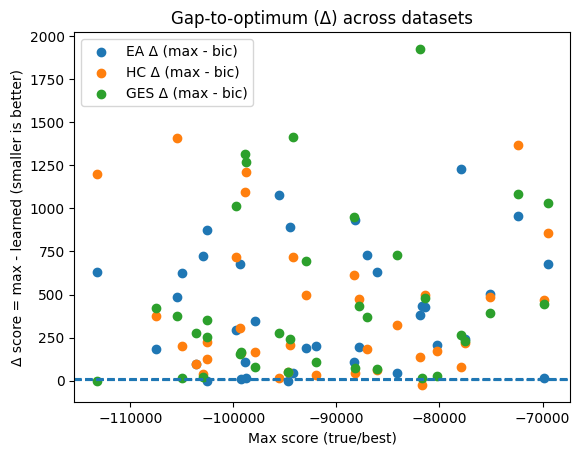

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

r_idx = 0
D = 36

# --- collect scores ---
ea_bic = np.array([ea[r_idx].bic_scores[d][-1] for d in range(D)], dtype=float)  # final greedy score
hc_bic = np.array([hc[r_idx].bic_scores[d]      for d in range(D)], dtype=float)
ges_bic= np.array([ges[r_idx].bic_scores[d]     for d in range(D)], dtype=float)

# pick one max_score vector (should be identical across algs if it's truly "the max/true")
max_score = np.array([ea[r_idx].max_score[d] for d in range(D)], dtype=float)

# optional sanity checks:
# print("max_score equals HC max_score?", np.allclose(max_score, [hc[r_idx].max_score[d] for d in range(D)]))
# print("max_score equals GES max_score?", np.allclose(max_score, [ges[r_idx].max_score[d] for d in range(D)]))

# --- build table + deltas (gap to max) ---
df = pd.DataFrame({
    "d": np.arange(D),
    "max_score": max_score,
    "ea_bic": ea_bic,
    "hc_bic": hc_bic,
    "ges_bic": ges_bic,
})

for alg in ["ea", "hc", "ges"]:
    df[f"delta_{alg}"] = df["max_score"] - df[f"{alg}_bic"]  # smaller is better

# --- summary comparison ---
summary = df[[f"delta_{a}" for a in ["ea","hc","ges"]]].agg(["mean","median","min","max"])
print(summary.T)

# which algorithm is closest to max most often?
df["best_alg"] = df[[f"delta_{a}" for a in ["ea","hc","ges"]]].idxmin(axis=1)
print(df["best_alg"].value_counts())

# how often within common “near-tie” thresholds?
for t in [2, 6, 10]:
    print(f"\nWithin Δ <= {t}:")
    for a in ["ea","hc","ges"]:
        print(f"  {a}: {(df[f'delta_{a}'] <= t).mean():.2%}")

# flag weird cases where learned score beats "max"
for a in ["ea","hc","ges"]:
    bad = df[df[f"delta_{a}"] < 0][["d","max_score",f"{a}_bic",f"delta_{a}"]]
    if len(bad):
        print(f"\nWARNING: {a} has {len(bad)} cases with delta < 0 (beats 'max'):\n", bad)

# --- quick plot: gap-to-max vs max_score ---
plt.scatter(df["max_score"], df["delta_ea"], label="EA Δ (max - bic)")
plt.scatter(df["max_score"], df["delta_hc"], label="HC Δ (max - bic)")
plt.scatter(df["max_score"], df["delta_ges"], label="GES Δ (max - bic)")
plt.axhline(2, linestyle="--")
plt.axhline(6, linestyle="--")
plt.axhline(10, linestyle="--")
plt.xlabel("Max score (true/best)")
plt.ylabel("Δ score = max - learned (smaller is better)")
plt.title("Gap-to-optimum (Δ) across datasets")
plt.legend()
plt.show()


               mean     median          min          max  wins(>0)  ties(=0)  \
EA - HC  -11.047385  26.165937 -1152.448706  1195.399348      18.0       1.0   
EA - GES  51.006622  21.040119  -966.146672  1547.255682      18.0       0.0   
HC - GES  62.054008  37.057973 -1203.099579  1791.735215      23.0       0.0   

          losses(<0)  within_2  within_6  within_10  
EA - HC         17.0  0.027778  0.027778   0.027778  
EA - GES        18.0  0.000000  0.000000   0.027778  
HC - GES        13.0  0.027778  0.027778   0.083333  


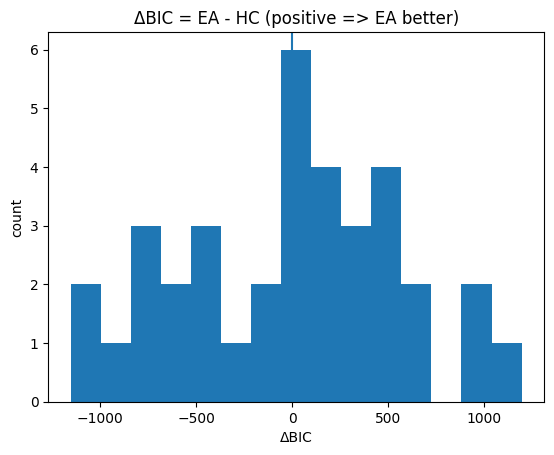

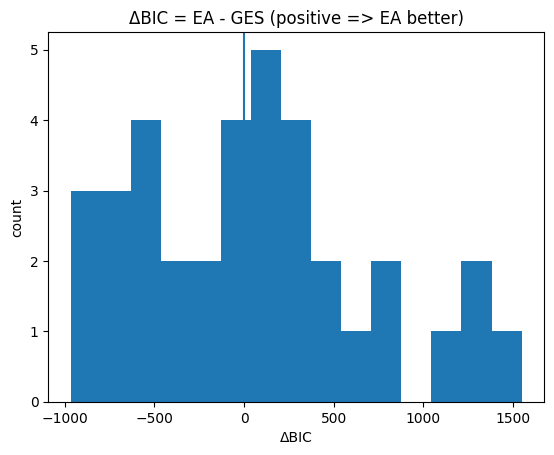

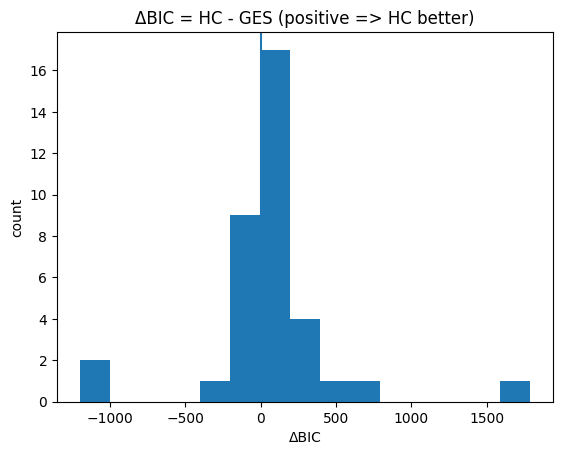

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

r_idx = 0
D = 36

ea_bic  = np.array([ea[r_idx].bic_scores[d][-1] for d in range(D)], dtype=float)  # final greedy
hc_bic  = np.array([hc[r_idx].bic_scores[d]      for d in range(D)], dtype=float)
ges_bic = np.array([ges[r_idx].bic_scores[d]     for d in range(D)], dtype=float)

df = pd.DataFrame({
    "d": np.arange(D),
    "ea": ea_bic,
    "hc": hc_bic,
    "ges": ges_bic,
})

# Pairwise deltas (higher is better, so positive means left beats right)
df["delta_ea_hc"]  = df["ea"]  - df["hc"]
df["delta_ea_ges"] = df["ea"]  - df["ges"]
df["delta_hc_ges"] = df["hc"]  - df["ges"]

# --- Summaries ---
def summarize_delta(col):
    x = df[col].to_numpy()
    return {
        "mean": np.mean(x),
        "median": np.median(x),
        "min": np.min(x),
        "max": np.max(x),
        "wins(>0)": int(np.sum(x > 0)),
        "ties(=0)": int(np.sum(x == 0)),
        "losses(<0)": int(np.sum(x < 0)),
        "within_2": float(np.mean(np.abs(x) <= 2)),
        "within_6": float(np.mean(np.abs(x) <= 6)),
        "within_10": float(np.mean(np.abs(x) <= 10)),
    }

summary = pd.DataFrame({
    "EA - HC": summarize_delta("delta_ea_hc"),
    "EA - GES": summarize_delta("delta_ea_ges"),
    "HC - GES": summarize_delta("delta_hc_ges"),
}).T

print(summary)

# --- Quick visualization: distributions of pairwise deltas ---
plt.figure()
plt.hist(df["delta_ea_hc"], bins=15)
plt.axvline(0)
plt.title("ΔBIC = EA - HC (positive => EA better)")
plt.xlabel("ΔBIC")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(df["delta_ea_ges"], bins=15)
plt.axvline(0)
plt.title("ΔBIC = EA - GES (positive => EA better)")
plt.xlabel("ΔBIC")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(df["delta_hc_ges"], bins=15)
plt.axvline(0)
plt.title("ΔBIC = HC - GES (positive => HC better)")
plt.xlabel("ΔBIC")
plt.ylabel("count")
plt.show()
